In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# ==========================================
# 1. LOAD AND MAP THE DATA 
# ==========================================
df = pd.read_csv('final_results.csv')

rename_dict = {
    'Type_1_Original': 'QS Baseline',
    'Type_2_Agnostic': 'Slightly Abstract',     
    'Type_7_Agnostic_Simple': 'Moderately Abstract', 
    'Type_3_Degraded_10': 'Slightly Incomplete',  
    'Type_4_Degraded_30': 'Moderately Incomplete',
    'Type_5_Error_10': 'Slightly Incorrect',      
    'Type_6_Error_30': 'Moderately Incorrect'     
}
df['Clean Rubric'] = df['Rubric ID'].map(rename_dict)

# Calculated raw difference (AI Score - Human Score) without the absolute value
df['Human Error'] = df['AI Normalized (Out of 10)'] - df['Human Normalized (Out of 10)']

df_pivot = df.pivot_table(
    index=['Problem ID', 'Submission ID'], 
    columns='Clean Rubric', 
    values='Human Error'
).reset_index()

# We include 'QS Baseline' here so all 7 are plotted!
columns_to_plot = [
    'QS Baseline',
    'Slightly Abstract', 'Moderately Abstract', 
    'Slightly Incomplete', 'Moderately Incomplete', 
    'Slightly Incorrect', 'Moderately Incorrect'
]

Saved: plot_directional_human_error.png


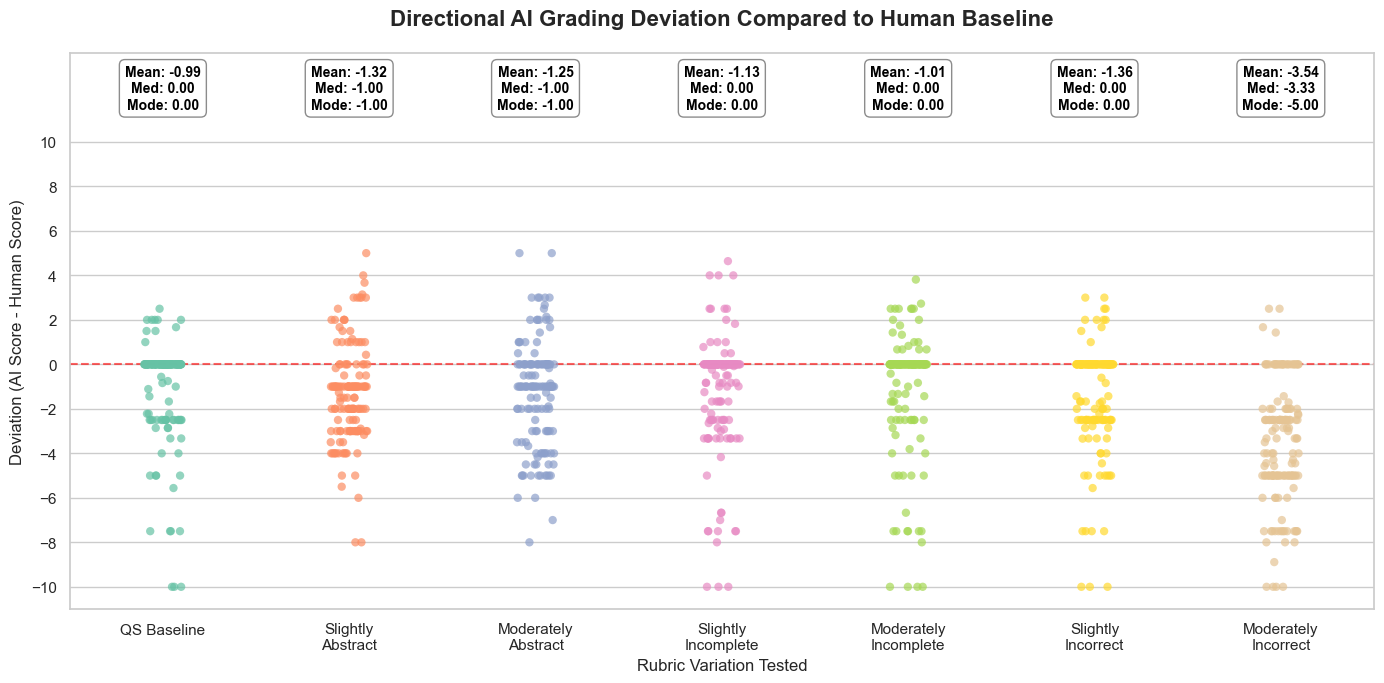

In [4]:
# ==========================================
# 2. THE PLOTTING ENGINE
# ==========================================
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7)) 

plot_data = df_pivot.melt(
    id_vars=['Problem ID', 'Submission ID'], 
    value_vars=columns_to_plot,
    var_name='Rubric Type', 
    value_name='Error'
)

sns.stripplot(x='Rubric Type', y='Error', data=plot_data, hue='Rubric Type',
              palette='Set2', legend=False, jitter=True, alpha=0.7, size=6)

# Zero error line (Perfect match with human)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Zero Error')

categories = plot_data['Rubric Type'].unique()
for i, cat in enumerate(categories):
    cat_data = plot_data[plot_data['Rubric Type'] == cat]['Error'].dropna()
    mean_val = cat_data.mean()
    median_val = cat_data.median()
    modes = cat_data.mode()
    mode_val = modes.iloc[0] if not modes.empty else 0
    
    stats_text = f"Mean: {mean_val:.2f}\nMed: {median_val:.2f}\nMode: {mode_val:.2f}"
    # Placed stats high enough to avoid overlapping with positive scatter points
    plt.text(i, 11.5, stats_text, horizontalalignment='center', size=10, 
             color='black', weight='semibold', 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.4'))

plt.title("Directional AI Grading Deviation Compared to Human Baseline", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Deviation (AI Score - Human Score)", fontsize=12)
plt.xlabel("Rubric Variation Tested", fontsize=12)

wrapped_labels = [textwrap.fill(cat, width=13) for cat in categories]
plt.xticks(range(len(categories)), wrapped_labels, fontsize=11)

# Adjusted y-axis bounds to show negative values properly
plt.ylim(-11, 14) 
plt.yticks(range(-10, 11, 2)) 
plt.tight_layout()

# Save the file automatically
filename = "plot_directional_human_error.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Saved: {filename}")

plt.show()